# Interconnection of port-Hamiltonian systems

This notebook will cover the implementation of interconnection schemes in this library.

In [37]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using TestPhsSolver

  Activating project at `c:\Users\horro\Git\hamilton-sim`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [26]:
a = [1.0 2.0; 3.0 4.0]
b = reshape([5.0; 6.0], :, 1)
c = reshape([7.0 8.0], 1, :)
d = reshape([9.0], 1, 1)

blockmatrix(a,b,c,d)

UndefVarError: UndefVarError: `blockmatrix` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [27]:
L = 1.0
C = 0.02533

R = 1.26 # underdamped
#R = 12.57 # critically damped
#R = 25.13 # overdamped
# Connecting an inductor into an capacitor

zeta = R/2 * sqrt(C/L)

display(zeta)

phs1 = inductor(L, s=1) 
phs2 = capacitor(C, s=-1);

0.10026702847895712

UndefVarError: UndefVarError: `inductor` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [28]:
ports = [PortPair(1, 1)];

UndefVarError: UndefVarError: `PortPair` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [29]:
ph_connect = connect(phs1, phs2, pairs=ports)

J = ph_connect.J
G = ph_connect.G

display(G)

blockmatrix(-J, -G, G', zeros(2, 2))

UndefVarError: UndefVarError: `ports` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [30]:
ph_total = connect_resistor(ph_connect, 1, R)

UndefVarError: UndefVarError: `connect_resistor` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [31]:
ph_total.R

UndefVarError: UndefVarError: `ph_total` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [32]:
dt = 0.01

sim_total = DescriptorSimulator(ph_total, dt, :Gauss1);

UndefVarError: UndefVarError: `DescriptorSimulator` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [33]:
x0 = [0.0, 1.0];
u = [0.0, 0.0]
tspan = 0.0:dt:10.0

t, states, output = simulate(sim_total, x0, u, tspan)



UndefVarError: UndefVarError: `simulate` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [34]:
plot_results(t, states; sys=ph_total)

UndefVarError: UndefVarError: `ph_total` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

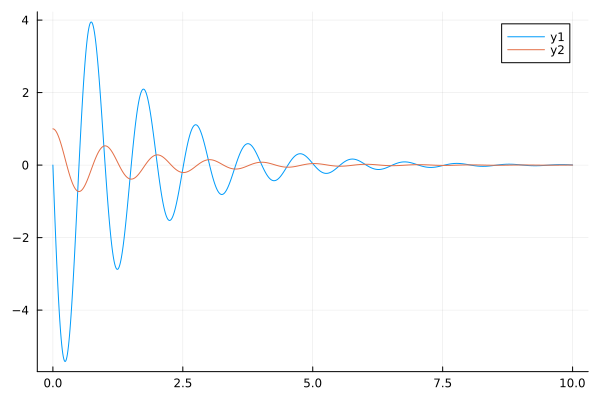

In [35]:
omega0 = 1/sqrt(L*C)
omegad = omega0*sqrt(1-zeta^2)
q(t) = exp.(-zeta*omega0*t).*(x0[2]*cos.(omegad*t) + x0[2]*(zeta*omega0/omegad)*sin.(omegad*t))
phi(t) = -L*x0[2]*(omega0^2/omegad)*exp.(-zeta*omega0.*t).*sin.(omegad.*t)


using Plots
plot(tspan, phi(tspan))
plot!(tspan, q(tspan))

In [36]:
# rethink the connection, we have artificial ports u1 u2 in the new system but it should be a closed one wihtout any ports, check reference and literature for theory!